# 02 — Preconditions, calibration, baseline network

Second of four (spec §9). Runs steps 0–2: preconditions (**G0 re-baselined, G2, G8**), the
per-part CWD + locked intra-name MSTs + band-cutoff **calibration** (step 1, written into
`run_config.json`), and the **baseline network** — locked + inter-name MST + β-augmentation,
criticality, bands, priority surface, v1 comparison, co-benefit audit (**G3/G4/G5**).

Creates the run dir (`output_data/corridors_north/v2_runNNN/`) that notebooks 03 and 04
re-attach to via their `RUN` variable.


In [32]:
# ---- Setup: find the project root, import the shared engines ----------------
# This notebook lives in analyses/northern_connectivity/, below the repo root where config.py
# and the corridor engine modules (corridors_prep / corridor_graph / corridors_core /
# corridors_ensemble) sit. Same bootstrap pattern as analyses/y2y/.
import sys, pathlib
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import config
import corridors_prep as cp
import corridor_graph as cg
import corridors_core as cc
import corridors_ensemble as ce
for _m in (config, cp, cg, cc, ce):
    importlib.reload(_m)

KEY = "north"


## Step 0 · Preconditions — **G2 / G8** re-assert, then the H7-gated run creation

`cc.resolve` is G8 (raises on any retired v1 key AND on any missing addendum key);
`cp.check` re-asserts warp fidelity on current disk state. `cc.start` then refuses to proceed
unless `multipart_review.csv` is SIGNED — it copies the H7 artifacts into the run dir and pins
their sha256. H1 (O'Brien licence sign-off) does NOT block the run; it blocks external release.


In [33]:
_ = cc.resolve(KEY, require_cutoff=False)          # G8
cp.check(cp.grid(KEY))                              # G2 re-assert


300 m routing grid (ESRI:102008): [-2205300, 1854900, -919800, 3585000]
  4,285 x 5,767 = 24.7 M cells @ 300 m   (lat >= 54.0)
G2 warp fidelity OK: 4,285 x 5,767 @ 300 m, ESRI:102008
  in-corridor cells 9,754,555 of 24,711,595 (39.5% of the window rectangle; the rest is outside the buffered Y2Y cutline)
  class distribution (share of in-corridor cells):
    cost     1:  88.2%  (8,600,713 cells)
    cost    10:   5.4%  (531,002 cells)
    cost   100:   0.3%  (25,325 cells)
    cost  1000:   6.1%  (597,515 cells)


{'valid_cells': 9754555,
 'classes': {1: 8600713, 10: 531002, 100: 25325, 1000: 597515}}

In [18]:
A = cc.start(KEY, label="v2 baseline", require_cutoff=False)
A


run v2_run002 (v2 baseline) -> output_data/corridors_north/v2_run002
  NOTE working tree is dirty; the recorded git SHA does not fully describe this run
Northern BC + Yukon: routing grid 2809x5767 @ 300 m = 9,696,945 routable cells (872,725 km²)
  cropped from the 4285x5767 warped window (66% of its cells) = anchors + 100 km routing buffer
  merged node: IPCA · Peel Watershed - SMA/WA absorbs Teetł’it Gwinjik (Peel River) (4,147 km² nested)
  merged node: PA · Nj ‘Iinlii” Jjik (Fishing Branch) Habitat Protection Area absorbs Fishing Branch Wilderness Preserve (5,355 km² nested)
  merged node: PA · Neah Conservancy absorbs Ne'ah – Horseranch Range Deadwood Lake Protected Area (2,312 km² nested)
nodes: 42 (10 IPCAs + 32 existing PAs >= 200 km²)  [min node size 25 km² = 278 cells @ 300 m]
  dropped 2 IPCA(s) below 25 km² in region: Wëdzey Nähuzhi (Matson Uplands), Łuk Tthe K’ät (Scottie Creek Wetlands)
  node land: 242,540 km² (excluded from the corridor)
D16 parts: 42 names -> 48 seed pa

<corridors v2_run002 | 42 nodes | 2809x5767>

### gate **G0** — re-baselined (D16): name set + dedupe merges + part count + review hash


In [19]:
cc.gate_g0(A, expect_names=42, expect_merges=3)


G0 OK (re-baselined): 42 names (3 dedupe merges) | 48 seed parts -> 42 routing units | review sha256 6304fec2c148


True

## Resistance · Phase 1.3 diagnostics


resistance = O'Brien et al., transboundary movement cost surface (extension of Pither et al. 2023)
  movement_cost.tif @ 300 m, 'near' resampled (ordinal classes preserved exactly)
resistance over 9,696,945 routable cells  (low = preferred corridor land)
    cost     1:  88.2%  (8,550,329 cells)
    cost    10:   5.4%  (526,913 cells)
    cost   100:   0.3%  (25,324 cells)
    cost  1000:   6.1%  (594,379 cells)
  p5=1  p50=1  p95=1000  max=1000
  EFFECTIVE SPREAD p95/p5 = 1,000x   (v1 blend was 10.9x)
  correlation with the v1 blend (log-log, 8,333,161 shared cells): r = +0.270
  wrote output_data/corridors_north/v2_run002/figures/resistance_diagnostics.png


<corridors v2_run002 | 42 nodes | 2809x5767>

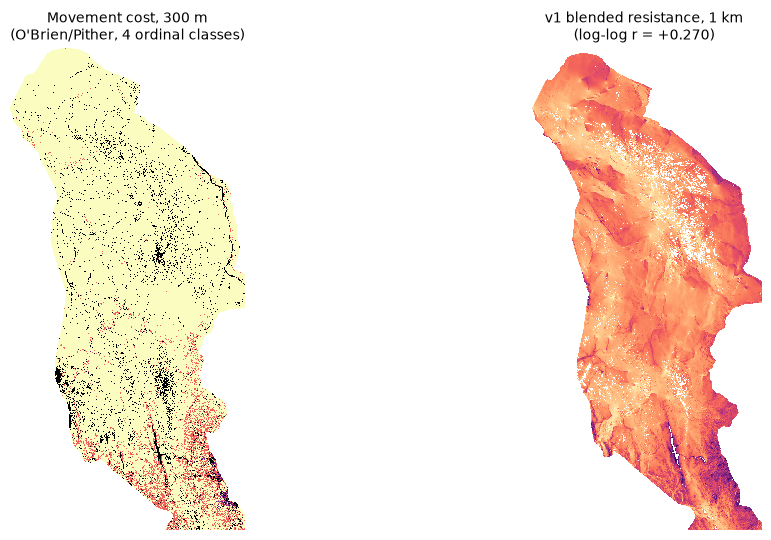

In [20]:
cc.resistance(A)
cc.resistance_report(A, v1_path=config.RESULTS_DIR / "corridors_north" / "_v1_frozen" / "resistance.tif")


## Step 1 · Cost-weighted distance — per SEED PART · the expensive stage

One MCP pass per part, cached by (resistance, part-structure) hash. Multi-part units get a
derived min-field (= multi-seed CWD from the part union — the D16 field semantics). Inter-name
distance between two multipart names = min over part pairs (standard multi-seed semantics).


In [21]:
cc.cost_distances(A)


cost-weighted distance from 48 seed parts (cache HIT: 148af4ab9b8b898a)
  cache 3.1 GB on disk, one field resident at a time


<corridors v2_run002 | 42 nodes | 2809x5767>

### Calibrate the absolute band cutoff (D6) — inter-name MST only, target 18,188 km²

`cc.set_cutoff` writes the calibrated value into THIS run's `run_config.json` (the engine's only
input after start), and reports the residual. Mirror it into
`config.CORRIDORS["north"]["cwd_cutoff_abs"]` manually if future runs should inherit it.


In [34]:
cutoff, area = cc.calibrate_cutoff(A)
cc.set_cutoff(A, cutoff, area)


calibrating cwd_cutoff_abs -> 18,188 km² on 41 mst edges
  iter  1: cutoff        652.6 ->    358,030 km²
  iter  2: cutoff        326.3 ->    238,949 km²
  iter  3: cutoff        163.2 ->    140,697 km²
  iter  4: cutoff         81.6 ->     78,159 km²
  iter  5: cutoff         40.8 ->     44,281 km²
  iter  6: cutoff         20.4 ->     24,287 km²
  iter  7: cutoff         10.2 ->     12,851 km²
  iter  8: cutoff         15.3 ->     19,993 km²
  iter  9: cutoff         12.7 ->     17,171 km²
  iter 10: cutoff         14.0 ->     18,654 km²
  iter 11: cutoff         13.4 ->     17,908 km²
  iter 12: cutoff         13.7 ->     18,284 km²
  iter 13: cutoff         13.5 ->     18,070 km²
  iter 14: cutoff         13.6 ->     18,150 km²

cwd_cutoff_abs = 13.6  reproduces 18,150 km² (target 18,188, mst edges; residual -38 km²)
  -> cc.set_cutoff(A, 13.6, 18150) writes it into run_config.json (and mirror it into config.CORRIDORS['north'] for future runs)
cwd_cutoff_abs = 13.6 written into v2

<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 32,938 km² | 10 segments>

## Step 2 · Network — locked intra-name MSTs + inter-name MST + bridge backup (D7/D16) · **gate G3**

Locked edges carry `edge_class="intra_name"`: real corridor land, included in criticality and
failure enumeration, band area reported as its own line (never folded into MST or augmentation
area). **G4** here reads as "β = 0 reproduces locked + inter-name MST" — locked edges are
appended regardless of β, so it holds by construction (and `cg.selftest` covers the β=0 MST).


In [35]:
cc.corridor_network(A)


  backup for IPCA · Dene Kʼéh Kusān <-> PA · Stikine River Park: add PA · Finlay Russel Park <-> PA · Stikine River Park  (111 = 2.06x)
  backup for IPCA · Dene Kʼéh Kusān <-> PA · Nahanni National Park Reserve Of Canada: add PA · Liard River Corridor Park <-> PA · Nahanni National Park Reserve Of Canada  (479 = 1.57x)
  backup for IPCA · Wədzih Yiné’ (Caribou Song) <-> PA · Finlay Russel Park: add IPCA · Wədzih Yiné’ (Caribou Song) <-> PA · Sustut Park  (141 = 1.61x)
  backup for IPCA · Tū Łī́dlini (Ross River) <-> PA · Ddhaw Ghro: add IPCA · Peel Watershed - SMA/WA (+1) <-> IPCA · Tū Łī́dlini (Ross River)  (456 = 1.75x)
  IRREPLACEABLE IPCA · Wədzih Yiné’ (Caribou Song) <-> PA · Chase Park  (cheapest alternative 16.4x > beta=2.5) -- 245 node pairs stranded if lost
  backup for PA · Chase Park <-> PA · Omineca Park: add IPCA · Wədzih Yiné’ (Caribou Song) <-> PA · Omineca Park  (213 = 1.23x)
  backup for PA · Carp Lake Park <-> PA · Omineca Park: add PA · Graham Laurier Park <-> PA · P

<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

### Criticality table — two irreplaceability senses, never merged

`irreplaceable` is the D7 β-ceiling flag (no alternative LINK). The D12 `route_irreplaceable`
flag (no alternative routing WITHIN a link) is added by notebook 04.


In [36]:
cols = ["label_i", "label_j", "edge_class", "cost", "in_mst", "is_adjacency", "ecfb_raw",
        "disconnects", "n_pairs_lost", "cost_inflation", "backup_ratio", "irreplaceable",
        "band_km2"]
A.edges[cols].sort_values(["irreplaceable", "n_pairs_lost"], ascending=False).head(20)


,label_i,label_j,edge_class,cost,in_mst,is_adjacency,ecfb_raw,disconnects,n_pairs_lost,cost_inflation,backup_ratio,irreplaceable,band_km2
edge_id,,,,,,,,,,,,,
E019_033,PA · Gwillim Lake Park,PA · Pine Le Moray Park,inter,248.929977,True,False,39.000000,True,117,inf,2.555613,True,868.23
L025_027,PA · Liard River Corridor Park [part 1],PA · Liard River Corridor Park [part 3],intra_name,5.242640,True,False,NaN,True,47,inf,4.644462,True,47.79
E005_039,IPCA · Wilps Gwininitxw,PA · Swan Lake Kispiox River Park,inter,86.556351,True,False,14.000000,True,41,inf,3.952485,True,397.71
E006_016,IPCA · Tthetäwndëk (Tatonduk),PA · Nj ‘Iinlii” Jjik (Fishing Branch) Habitat...,inter,9.000000,True,False,14.000000,True,41,inf,19.235538,True,103.05
E017_035,PA · Gladys Lake Ecological Reserve,PA · Spatsizi Plateau Wilderness Park,inter,1.000000,True,False,14.000000,True,41,inf,46.899494,True,659.61
E009_011,IPCA · Wədzih Yiné’ (Caribou Song),PA · Chase Park,inter,13.000000,True,False,34.315779,False,0,29.681535,16.393834,True,127.98
E026_036,PA · Mount Edziza Park,PA · Stikine River Park,inter,1.000000,True,False,20.749866,False,0,269.161476,141.350296,True,146.61
L032_033,PA · Nahanni National Park Reserve Of Canada [...,PA · Nahanni National Park Reserve Of Canada [...,intra_name,36.485283,True,False,NaN,True,407,inf,0.027408,False,256.77
L002_003,IPCA · Dene Kʼéh Kusān [part 2],IPCA · Dene Kʼéh Kusān [part 3],intra_name,48.769554,True,False,NaN,True,47,inf,2.489196,False,387.54


## Linkage priority surface (D9) + maps

Note the flagged OPEN METHODS QUESTION: locked intra-name edges have undefined quotient-graph
centrality (like adjacencies), so their land shows in `corridors.tif` and the near-optimality
surface but contributes nothing to `linkage_priority.tif`.


In [37]:
cc.priority_surface(A)


linkage priority surface over 367,119 corridor cells
  robust_core  (>= p90):    3,250 km²
  frequent     (>= p70):    6,288 km²
  occasional   (>= p 0):   22,255 km²


<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

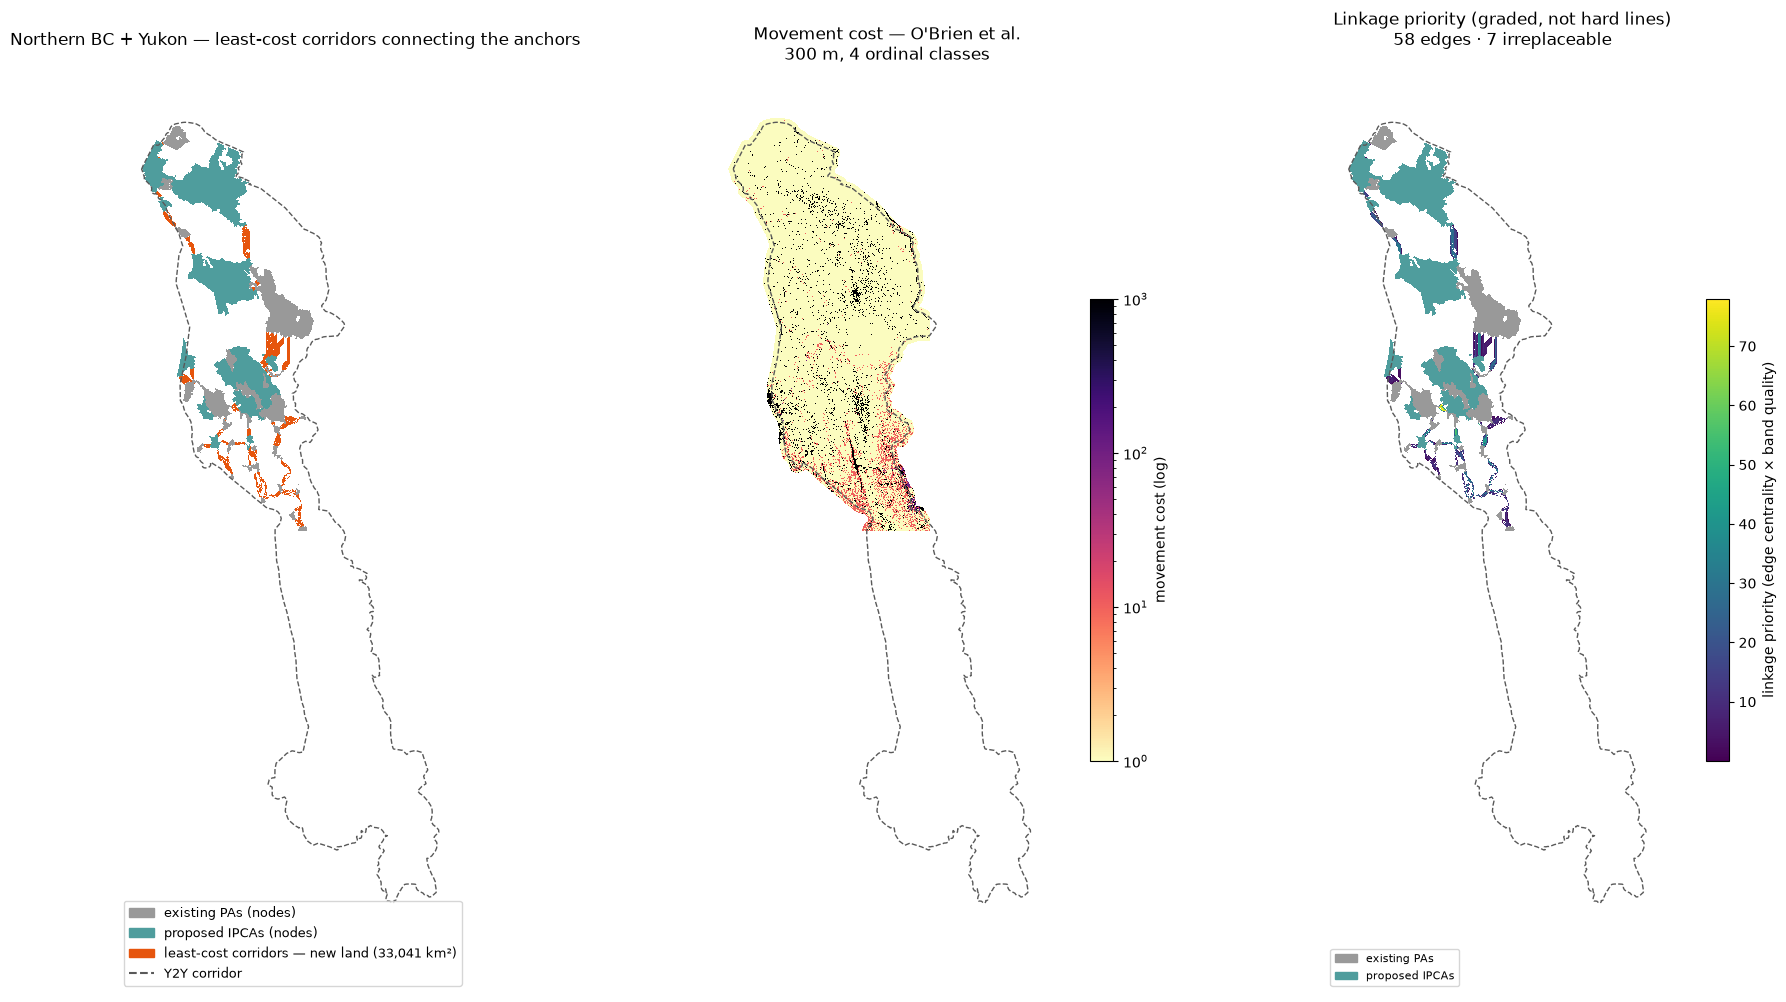

<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

In [38]:
cc.map(A)


## Compare against v1


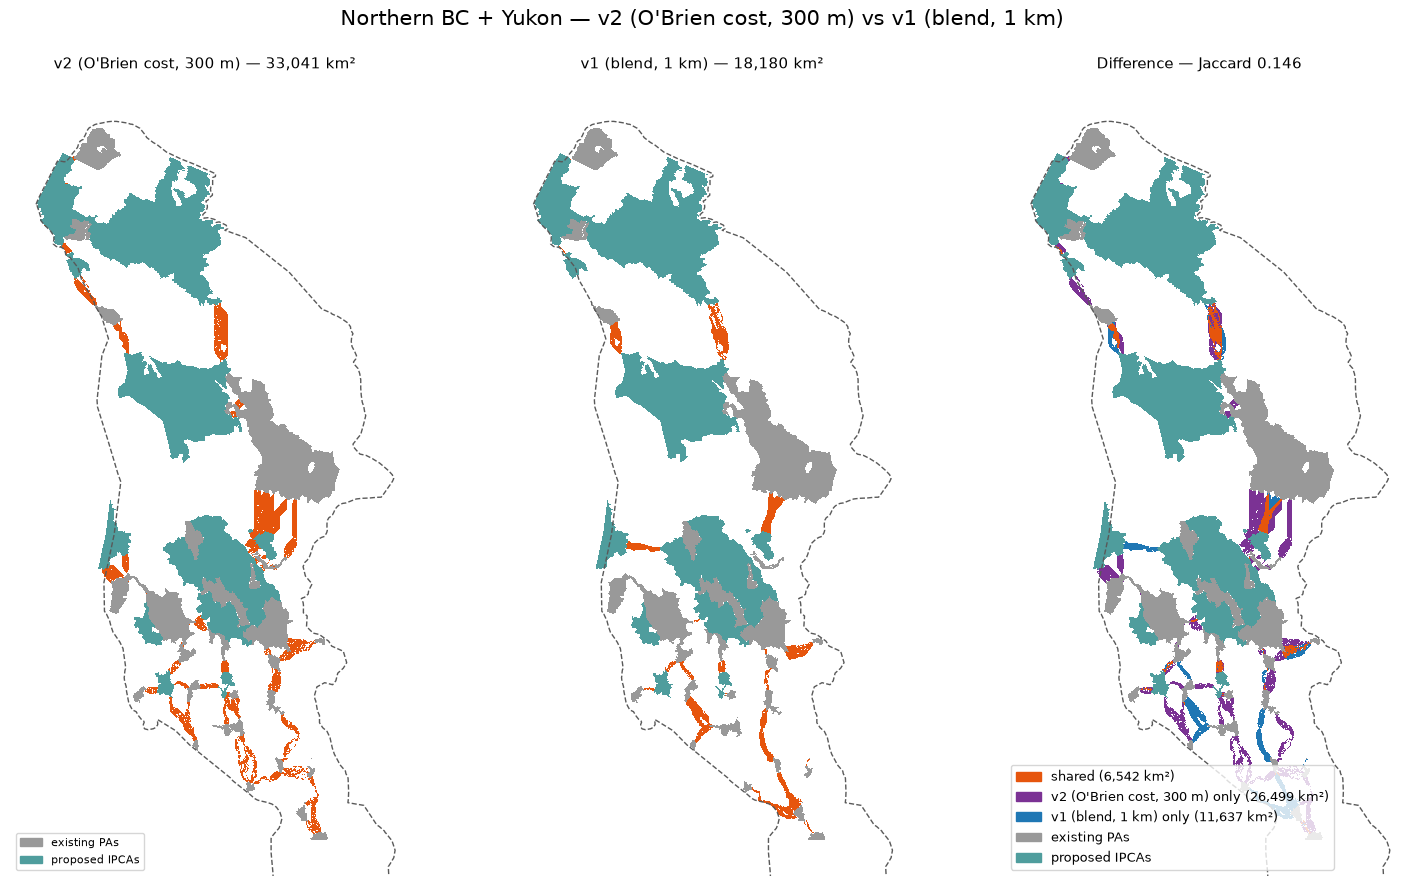

Jaccard v2 (O'Brien cost, 300 m) vs v1 (blend, 1 km): 0.146


In [39]:
j = cc.compare(A, config.RESULTS_DIR / "corridors_north" / "_v1_frozen",
               label_a="v2 (O'Brien cost, 300 m)", label_b="v1 (blend, 1 km)")


## Co-benefit audit · **gate G5** — 300 m masks crossed to the 1 km audit grid


corridor segments: 71 components merged by location into 10 clusters (100% of corridor area — all of it)
  multi-part clusters: 1 = 7 components; 2 = 11 components; 3 = 4 components; 4 = 15 components; 5 = 4 components; 6 = 6 components; 8 = 14 components; 9 = 6 components; 10 = 3 components
  building 8 continuous + 40 EFG stacks on the 1000 m AUDIT grid…
  crossing masks 300 m -> 1 km for profiling:
  OK  audit grid: 1. IPCA · Peel Watershed - SMA/WA (+1) 3,996 km² @300 m -> 4,139 km² @1 km (+3.6%)
  OK  audit grid: 2. IPCA · Peel Watershed - SMA/WA (+1) 2,830 km² @300 m -> 2,871 km² @1 km (+1.5%)
  OK  audit grid: 3. IPCA · Dene Kʼéh Kusān ↔ PA · Liard 2,079 km² @300 m -> 2,109 km² @1 km (+1.4%)
  OK  audit grid: 4. IPCA · Dene Kʼéh Kusān ↔ IPCA · T’a 8,743 km² @300 m -> 8,825 km² @1 km (+0.9%)
  OK  audit grid: 5. PA · Graham Laurier Park ↔ PA · Klu 3,130 km² @300 m -> 3,280 km² @1 km (+4.8%)
  OK  audit grid: 6. IPCA · Dene Kʼéh Kusān ↔ IPCA · Wəd 2,880 km² @300 m -> 2,960 km² @1 

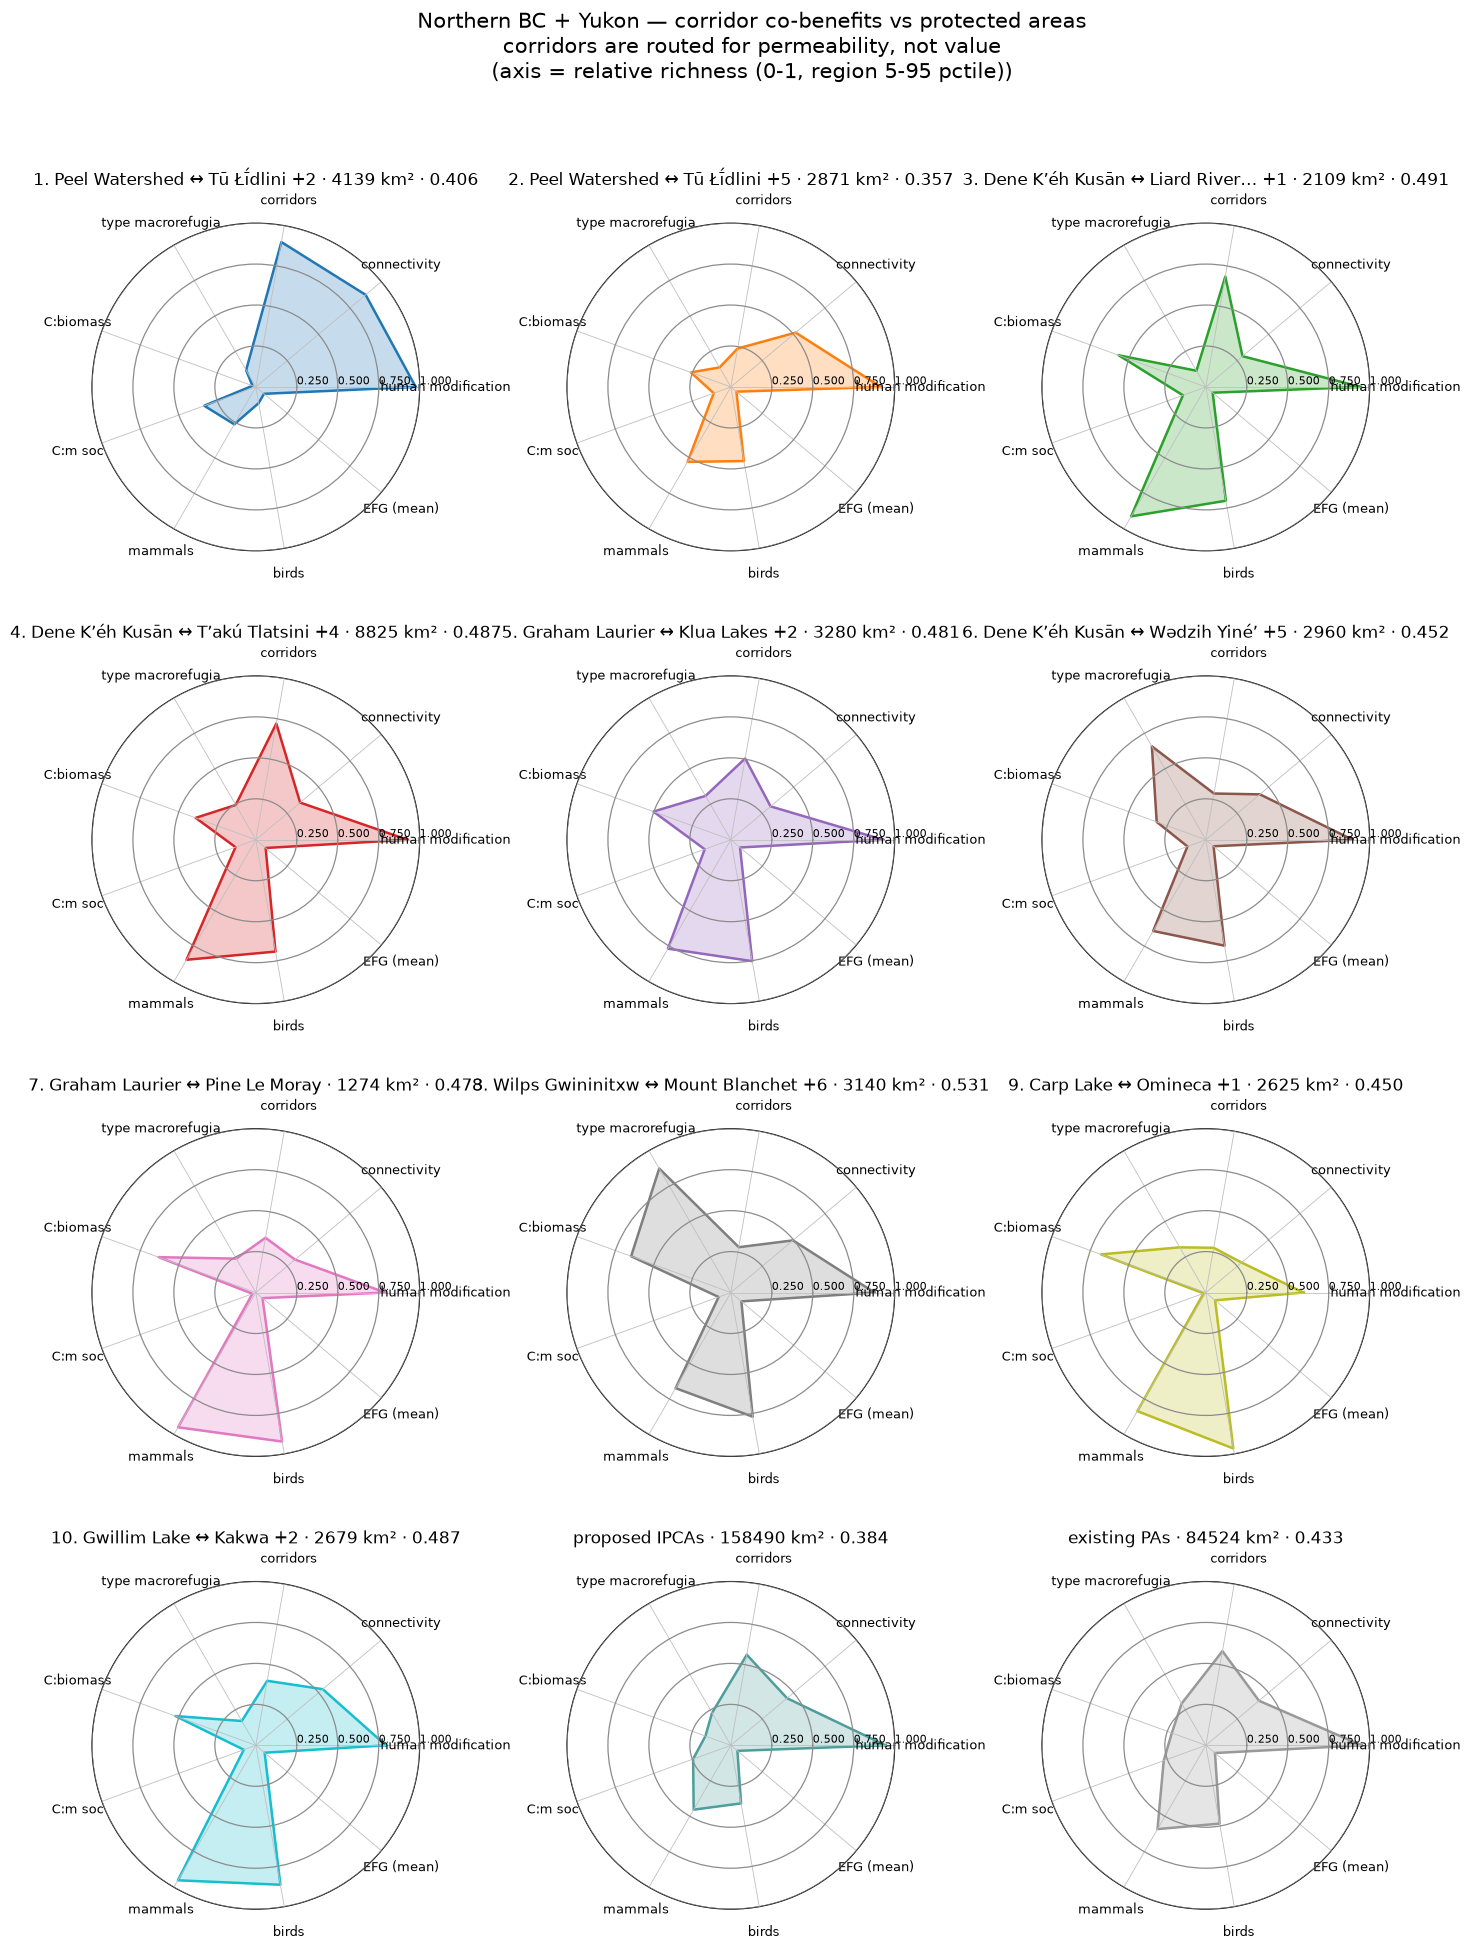

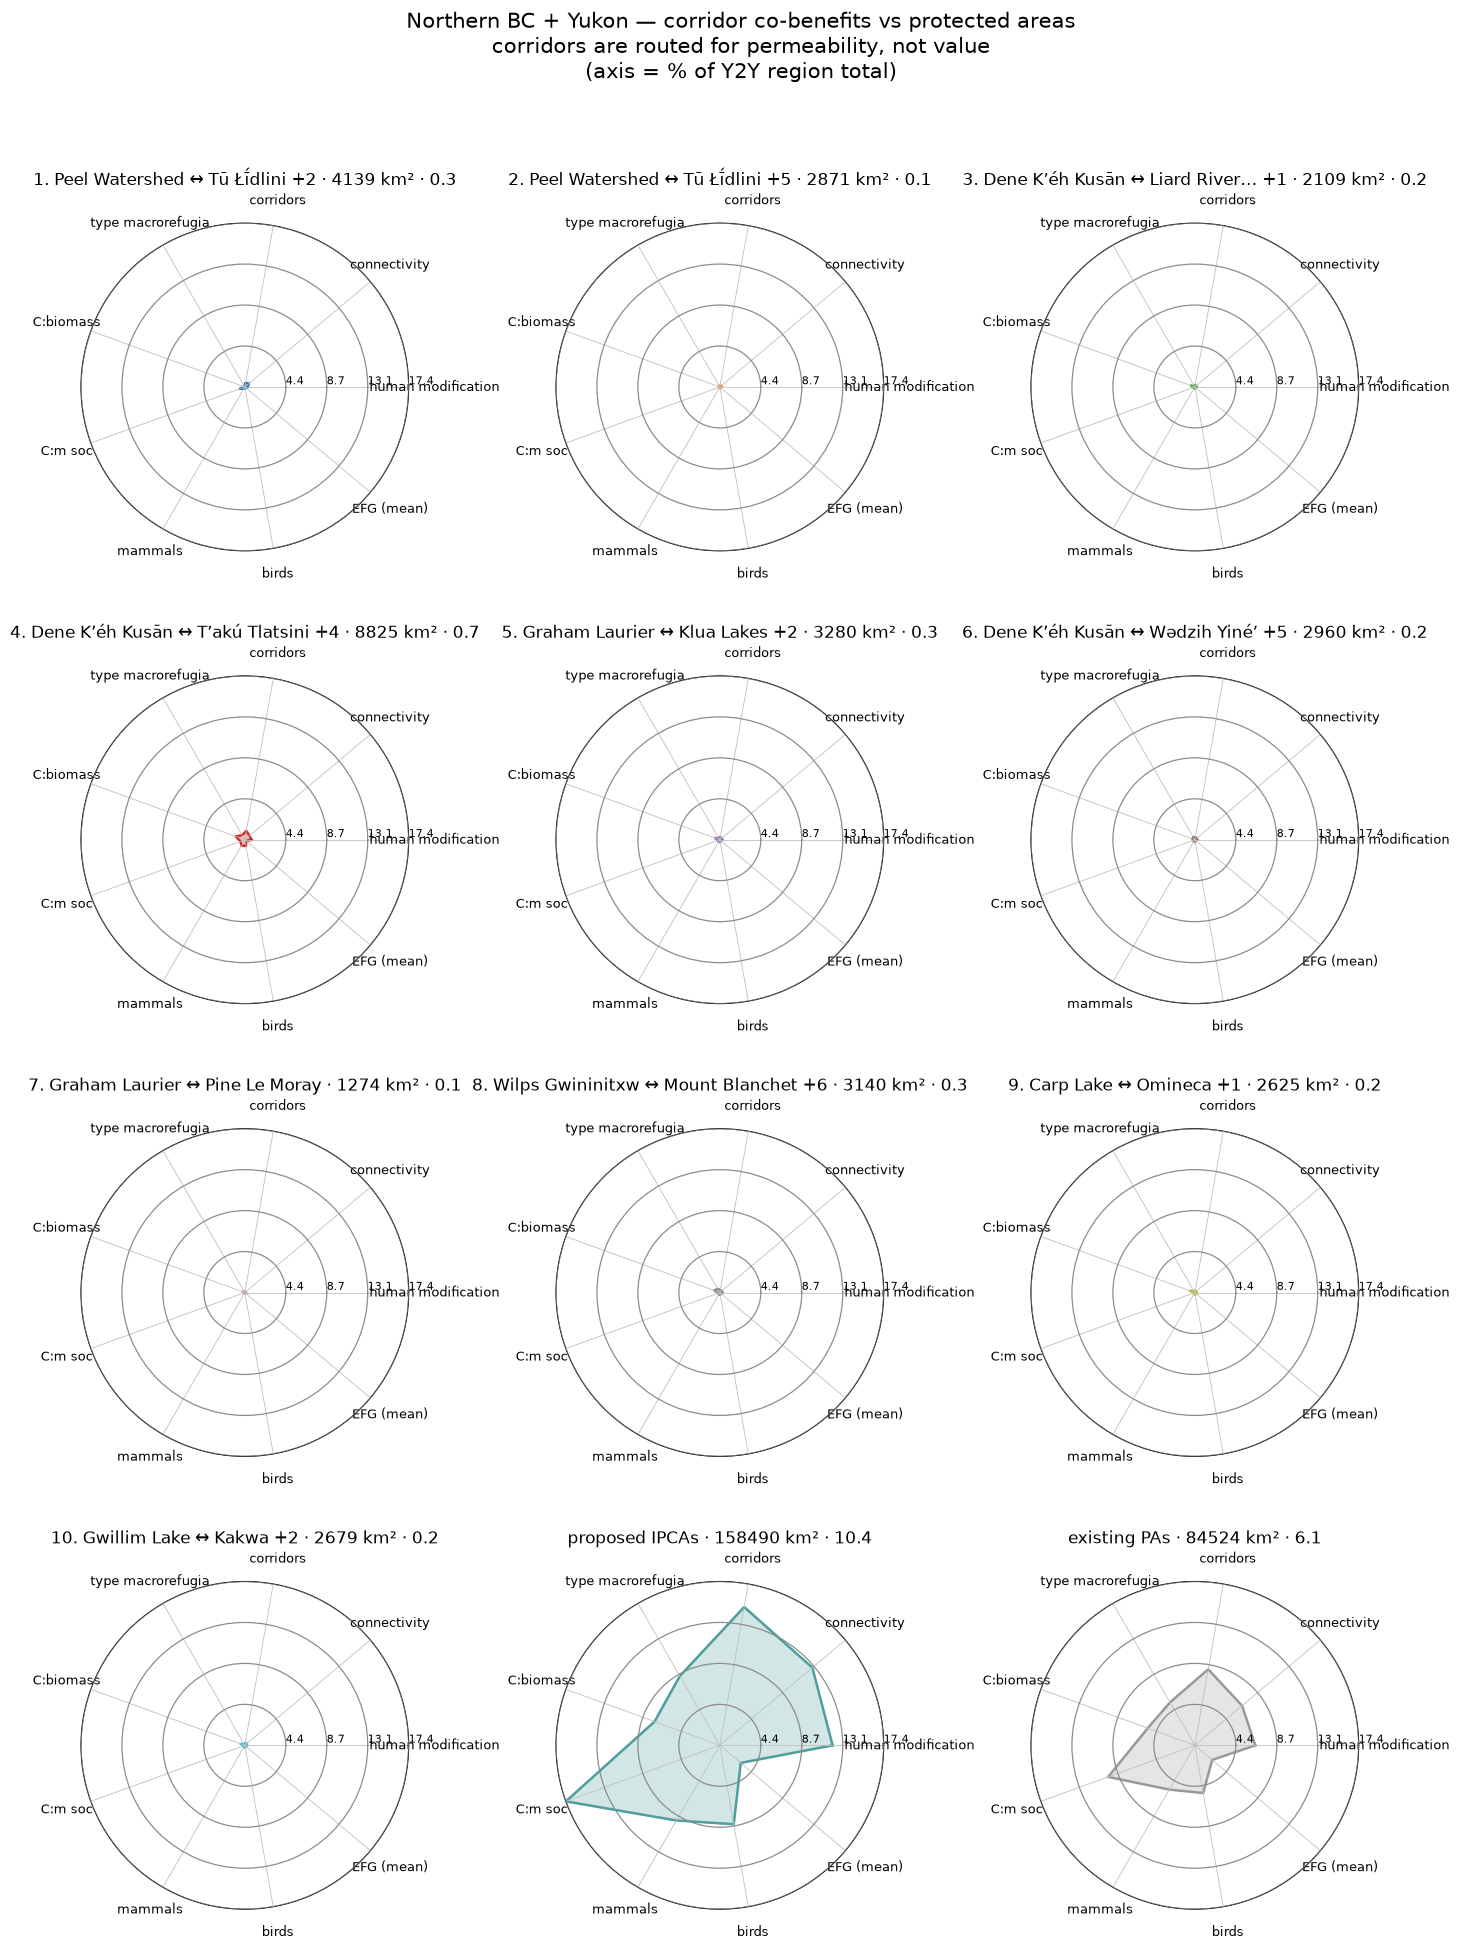

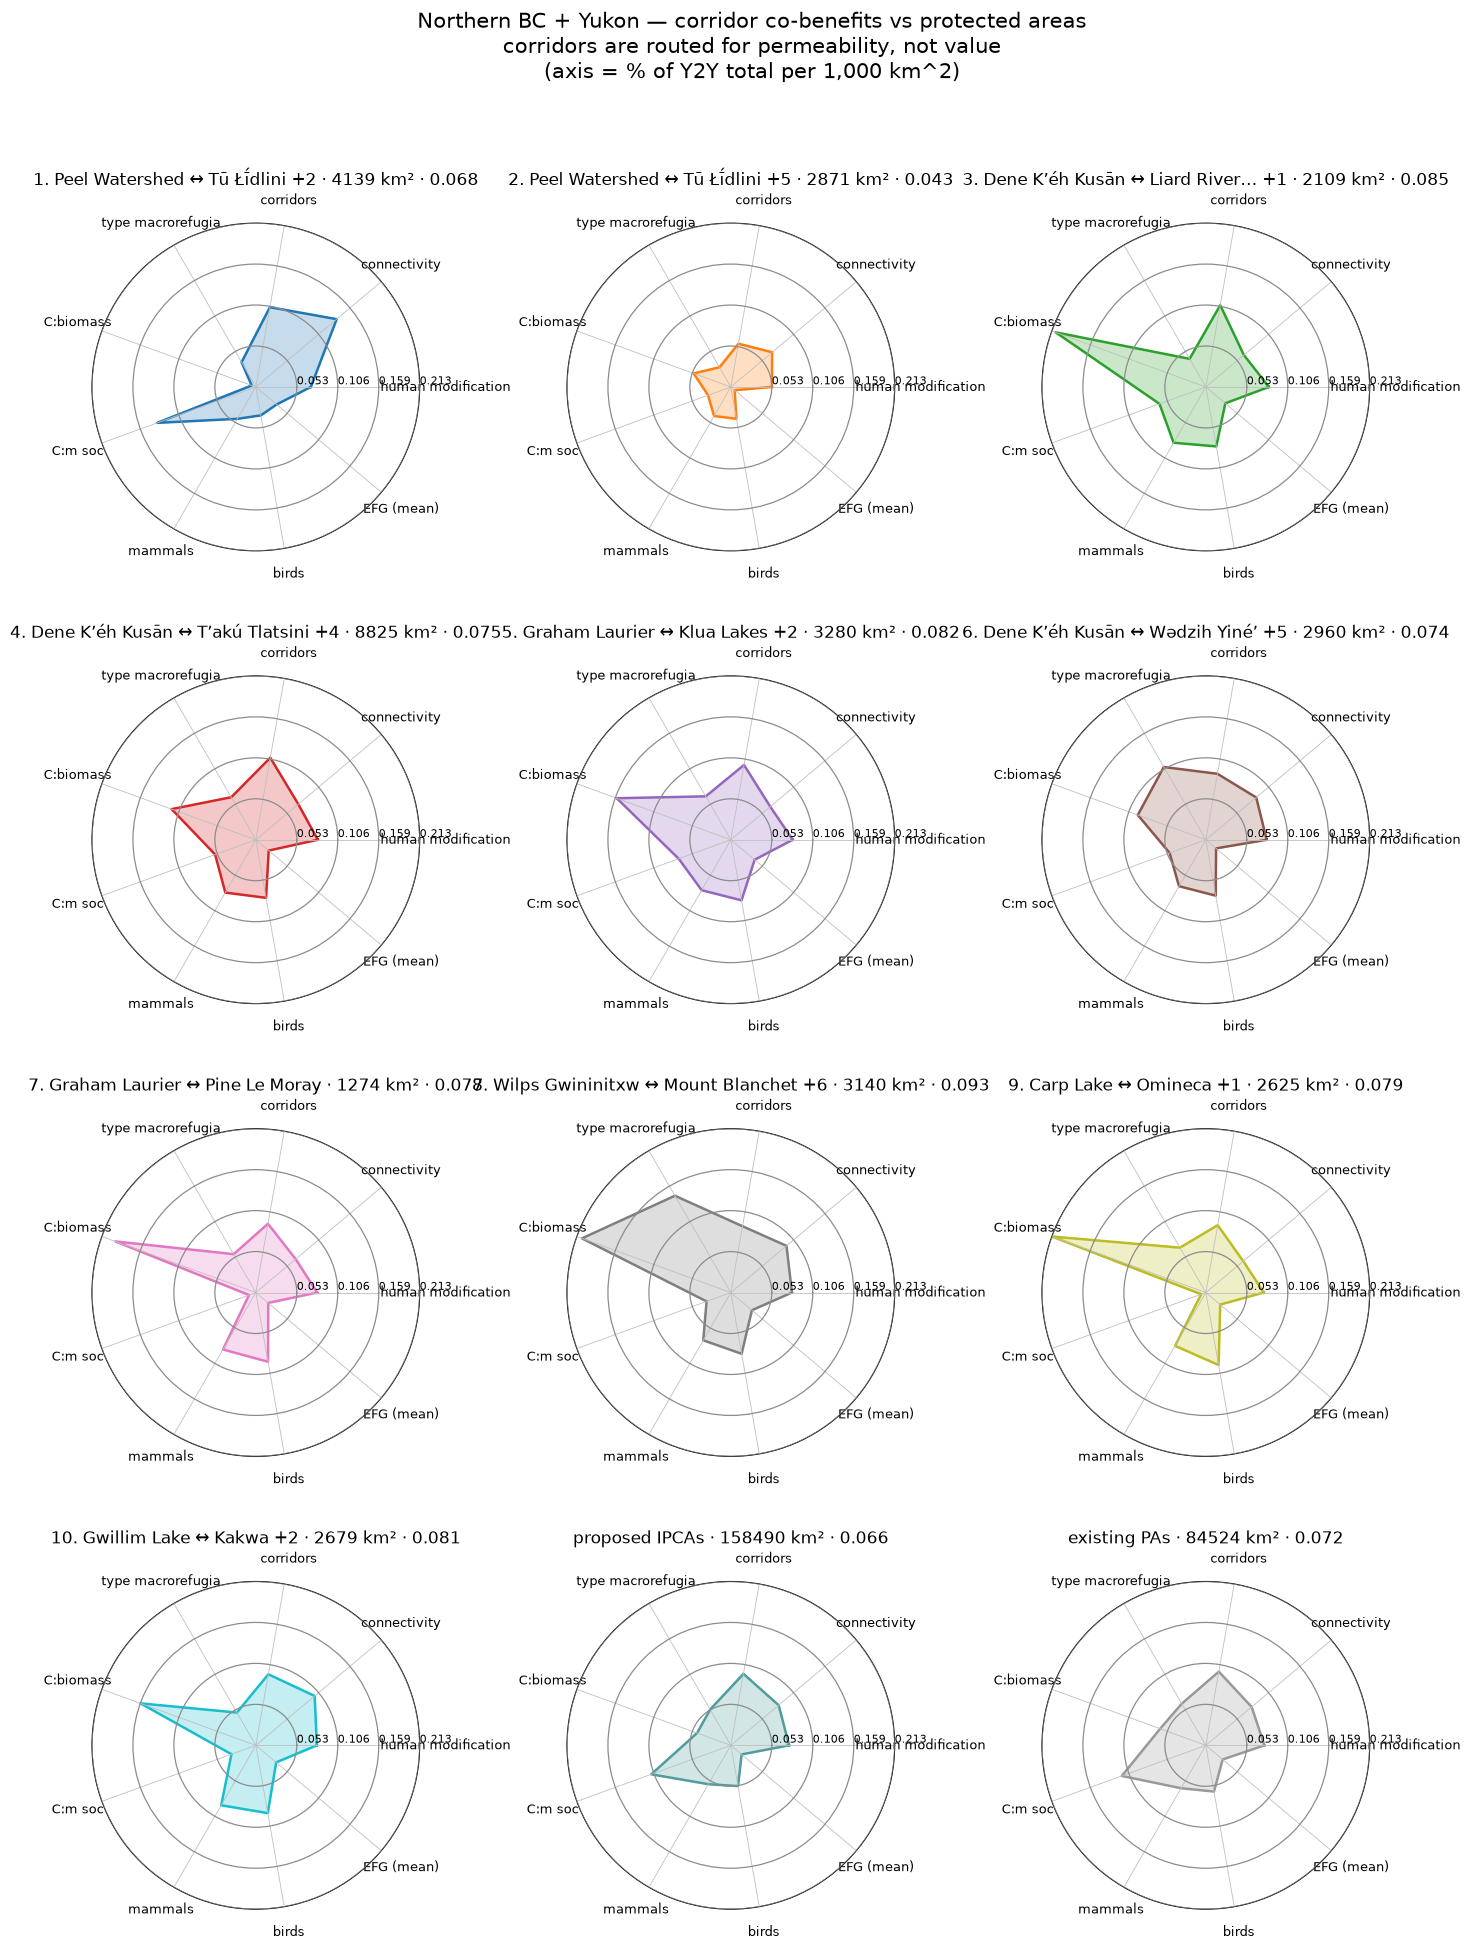

  wrote corridor_profile.csv


<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

In [40]:
cc.corridor_profile(A, n_groups=10)


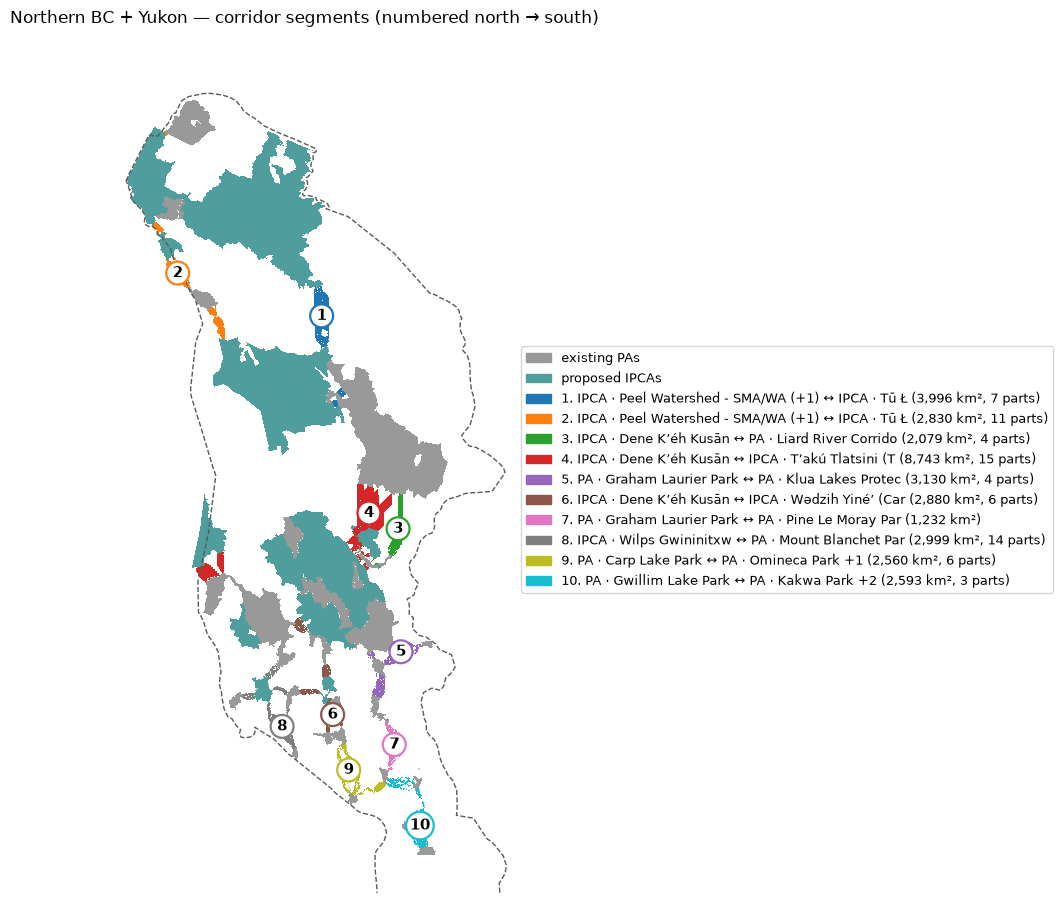

<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>

In [41]:
cc.corridor_group_map(A)


### gate G5 — audit invariance (v1's IPCA / PA profile rows reproduce)


In [42]:
# gate G5 -- audit invariance: v1's IPCA / PA rows must reproduce on every axis whose FEATURE
# DEFINITION is unchanged. climate_type_macrorefugia is EXCLUDED from the assert and reported
# instead: v1's profile froze 2026-08-07 against the vmax−v orientation, and the 2026-08-17
# leverage redesign re-oriented the hand-off layer to 1/v (manifest orient="reciprocal") -- on
# that axis the gate compares two DIFFERENT features, so its delta is the expected consequence
# of a documented methods change, not an audit-path regression. Measured on v2_run002:
# -0.275 (IPCAs) / -0.260 (PAs) -- the right-skewed 1/v sits low after the 5-95 stretch.
# (Also fixed: the column filter now matches only "| richness" -- the old `"richness" in c`
# accidentally swept in the AOH "aoh richness ... | contribution %" columns.)
import pandas as pd, numpy as np
old = pd.read_csv(config.RESULTS_DIR / "corridors_north" / "_v1_frozen" / "corridor_profile.csv")
new = A.profile["table"]
REORIENTED = ("climate type macrorefugia",)        # feature re-defined after v1 froze
for area in ("proposed IPCAs", "existing PAs"):
    o = old[old.area == area].iloc[0]; n = new[new.area == area].iloc[0]
    cols = [c for c in new.columns if c.endswith("| richness") and c in old.columns]
    inv = [c for c in cols if not any(k in c for k in REORIENTED)]
    d = max(abs(float(o[c]) - float(n[c])) for c in inv)
    print(f"  {area:16s} max |Δrichness| over {len(inv)} unchanged axes = {d:.4f}")
    for c in cols:
        if any(k in c for k in REORIENTED):
            print(f"    excluded ({c.split(' |')[0]}: re-oriented vmax−v -> 1/v, 2026-08-17): "
                  f"v1 {float(o[c]):.3f} -> v2 {float(n[c]):.3f}")
    assert d < 0.02, f"G5 FAILED on {area}: the audit path changed (max Δ {d:.4f})"
print("G5 OK — audit path unchanged; the macrorefugia delta is the documented re-orientation")


  proposed IPCAs   max |Δrichness| over 8 unchanged axes = 0.0020
    excluded (climate type macrorefugia: re-oriented vmax−v -> 1/v, 2026-08-17): v1 0.504 -> v2 0.229
  existing PAs     max |Δrichness| over 8 unchanged axes = 0.0020
    excluded (climate type macrorefugia: re-oriented vmax−v -> 1/v, 2026-08-17): v1 0.555 -> v2 0.295
G5 OK — audit path unchanged; the macrorefugia delta is the documented re-orientation


## Write the core outputs

`corridor_summary.json` is also the run's "done" marker in `runs.csv`. Notebook 04's
`cc.finish` re-writes it after the D11/D12 products add their columns.


In [43]:
cc.write_run(A)


  wrote output_data/corridors_north/v2_run002/corridors.tif
  wrote output_data/corridors_north/v2_run002/resistance.tif
  wrote output_data/corridors_north/v2_run002/corridors.gpkg
  wrote output_data/corridors_north/v2_run002/linkage_priority.tif
  wrote output_data/corridors_north/v2_run002/linkage_priority_class.tif
  wrote output_data/corridors_north/v2_run002/edge_owner.tif
  wrote output_data/corridors_north/v2_run002/corridor_edges.csv
  wrote output_data/corridors_north/v2_run002/criticality.csv
  wrote output_data/corridors_north/v2_run002/corridor_edges.gpkg
  wrote output_data/corridors_north/v2_run002/corridor_summary.json


<corridors v2_run002 | 42 nodes | 2809x5767 | 58 edges | corridor 33,041 km² | 10 segments>